In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from joblib import Parallel, delayed
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
import scipy.stats as stats


In [2]:
df_2022=pd.read_csv('fifa_ranking_2022-10-06.csv')
df_2026=pd.read_csv('fifa_ranking_2026-06-08.csv')
df_matches=pd.read_csv('matches_1930_2022.csv')
df_shedule=pd.read_csv('schedule_2026.csv')
df_world_cup=pd.read_csv('world_cup.csv')
df=pd.DataFrame()


In [3]:
#trying to find total teams from 1930 to 2022
match_teams = set(df_matches['home_team'].dropna().unique()).union(set(df_matches['away_team'].dropna().unique()))

# total teams in 2022 
ranking_teams = set(df_2022['team'].dropna().unique())

# team that are not in 2022 bit were there in btw 1930 to 2022
missing_in_rankings = sorted(list(match_teams - ranking_teams))

print(f"Total unique teams in Matches: {len(match_teams)}")
print(f"Total unique teams in Rankings: {len(ranking_teams)}")
print(f"Number of mismatches: {len(missing_in_rankings)}")
print("Mismatched Teams:", missing_in_rankings)

Total unique teams in Matches: 86
Total unique teams in Rankings: 211
Number of mismatches: 11
Mismatched Teams: ['Czech Republic', 'Czechoslovakia', 'Dutch East Indies', 'FR Yugoslavia', 'Germany DR', 'Serbia and Montenegro', 'Soviet Union', 'United States', 'West Germany', 'Yugoslavia', 'Zaire']


In [4]:
country_mapping = {
    'United States': 'USA',
    'Czech Republic': 'Czechia',
    'Czechoslovakia': 'Czechia',
    'Dutch East Indies': 'Indonesia',
    'FR Yugoslavia': 'Serbia',
    'Germany DR': 'Germany',
    'Serbia and Montenegro': 'Serbia',
    'Soviet Union': 'Russia',
    'West Germany': 'Germany',
    'Yugoslavia': 'Serbia',
    'Zaire': 'Congo DR'
}

df_matches['home_team'] = df_matches['home_team'].replace(country_mapping)
df_matches['away_team'] = df_matches['away_team'].replace(country_mapping)

In [6]:
#
# We check if 'home_penalty' is NOT null. If it's not null, a shootout happened.
df_matches['went_to_shootout'] = df_matches['home_penalty'].notna().astype(int)
df_matches['home_penalty'] = df_matches['home_penalty'].fillna(0)
df_matches['away_penalty'] = df_matches['away_penalty'].fillna(0)


# Assuming 'df' is your DataFrame and 'your_column' is the column name
df_matches['home_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_red_card'] = df_matches['away_red_card'].notna().astype(int)
df_matches['home_yellow_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_yellow_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_own_goal'] = df_matches['away_own_goal'].notna().astype(int)
df_matches['home_own_goal'] = df_matches['home_own_goal'].notna().astype(int)




df_matches['Match_Result'] = np.where(
    df_matches['home_score'] > df_matches['away_score'], 0,
    np.where(
        df_matches['home_score'] < df_matches['away_score'], 1,
        2
    )
)



Merged Ranking Data Head:
        team team_code_2022 association_2022  rank_2022  previous_rank_2022  \
0     Brazil            BRA         CONMEBOL          1                   1   
1    Belgium            BEL             UEFA          2                   2   
2  Argentina            ARG         CONMEBOL          3                   3   
3     France            FRA             UEFA          4                   4   
4    England            ENG             UEFA          5                   5   

   points_2022  previous_points_2022 team_code_2026 association_2026  \
0      1841.30               1837.56            BRA         CONMEBOL   
1      1816.71               1821.92            BEL             UEFA   
2      1773.88               1770.65            ARG         CONMEBOL   
3      1759.78               1764.85            FRA             UEFA   
4      1728.47               1737.46            ENG             UEFA   

   rank_2026  previous_rank_2026  points_2026  previous_points_20

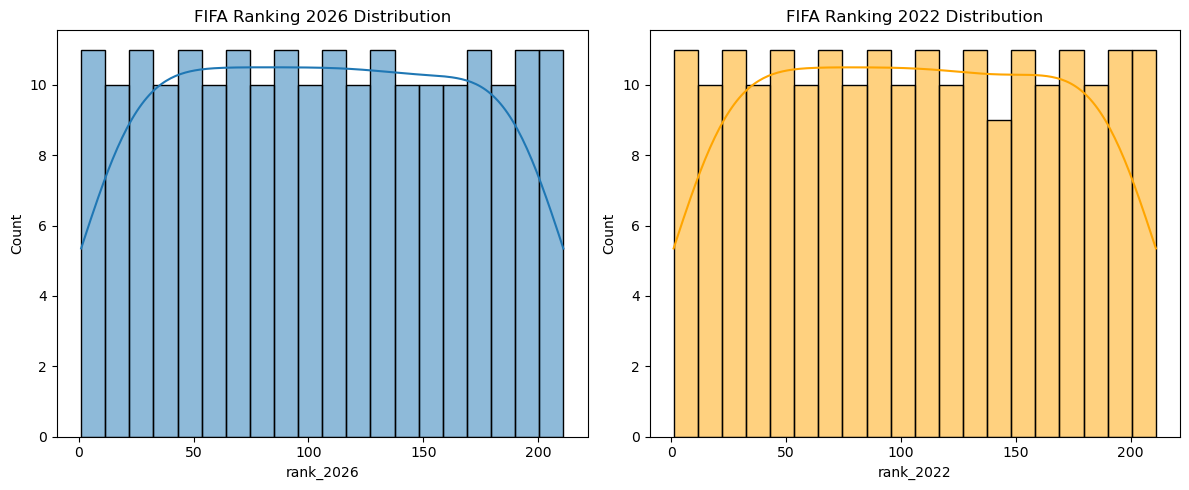

In [7]:
df_ranking = pd.merge(df_2022, df_2026, on='team', suffixes=('_2022', '_2026'))
print('\nMerged Ranking Data Head:')
print(df_ranking.head())

# Plotting the distribution of ranks for both years using histograms
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.histplot(df_ranking['rank_2026'], bins=20, kde=True)
plt.title('FIFA Ranking 2026 Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_ranking['rank_2022'], bins=20, kde=True, color='orange')
plt.title('FIFA Ranking 2022 Distribution')
plt.tight_layout()
plt.show()

In [8]:
df_ranking.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   team                  210 non-null    str    
 1   team_code_2022        210 non-null    str    
 2   association_2022      210 non-null    str    
 3   rank_2022             210 non-null    int64  
 4   previous_rank_2022    210 non-null    int64  
 5   points_2022           210 non-null    float64
 6   previous_points_2022  210 non-null    float64
 7   team_code_2026        210 non-null    str    
 8   association_2026      210 non-null    str    
 9   rank_2026             210 non-null    int64  
 10  previous_rank_2026    210 non-null    int64  
 11  points_2026           210 non-null    float64
 12  previous_points_2026  210 non-null    float64
 13  rated_matches         210 non-null    int64  
dtypes: float64(4), int64(5), str(5)
memory usage: 23.1 KB


In [9]:
df_ranking.describe()

,rank_2022,previous_rank_2022,points_2022,previous_points_2022,rank_2026,previous_rank_2026,points_2026,previous_points_2026,rated_matches
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,105.814286,105.804762,1221.441143,1221.418333,105.771429,105.766667,1230.931356,1230.936652,45.876190
std,61.140741,61.134450,253.789277,253.687655,61.109950,61.106134,278.365798,278.109655,16.336881
min,1.000000,1.000000,762.220000,763.820000,1.000000,1.000000,722.933728,726.330601,7.000000
25%,53.250000,53.250000,1007.567500,1006.540000,53.250000,53.250000,1008.687970,1006.087272,35.000000
50%,105.500000,105.500000,1193.035000,1188.840000,105.500000,105.500000,1193.426238,1193.306601,48.000000
75%,158.750000,158.750000,1434.072500,1433.765000,158.750000,158.750000,1455.817657,1455.725265,56.000000
max,211.000000,211.000000,1841.300000,1837.560000,211.000000,211.000000,1876.118331,1877.322731,87.000000


In [10]:
numeric_df_matches = df_matches.select_dtypes(include=[np.number])
numeric_df_matches.corr()

,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,Attendance,Year,home_own_goal,away_own_goal,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,went_to_shootout,Match_Result
home_score,1.000000,0.621172,-0.091463,0.005215,-0.133290,-0.095994,-0.095617,-0.339134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.523627
home_xg,0.621172,1.000000,-0.004236,0.037534,-0.266932,-0.040310,0.007194,-0.063811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.319405
home_penalty,-0.091463,-0.004236,1.000000,-0.012001,0.167949,0.875843,0.093867,0.111076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.296398
away_score,0.005215,0.037534,-0.012001,1.000000,0.475121,-0.018688,-0.036464,0.078814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.217635
away_xg,-0.133290,-0.266932,0.167949,0.475121,1.000000,0.151847,-0.071096,0.096918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.284207
away_penalty,-0.095994,-0.040310,0.875843,-0.018688,0.151847,1.000000,0.096511,0.107121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.296558
Attendance,-0.095617,0.007194,0.093867,-0.036464,-0.071096,0.096511,1.000000,0.297490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.006266
Year,-0.339134,-0.063811,0.111076,0.078814,0.096918,0.107121,0.297490,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.226184
home_own_goal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_own_goal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


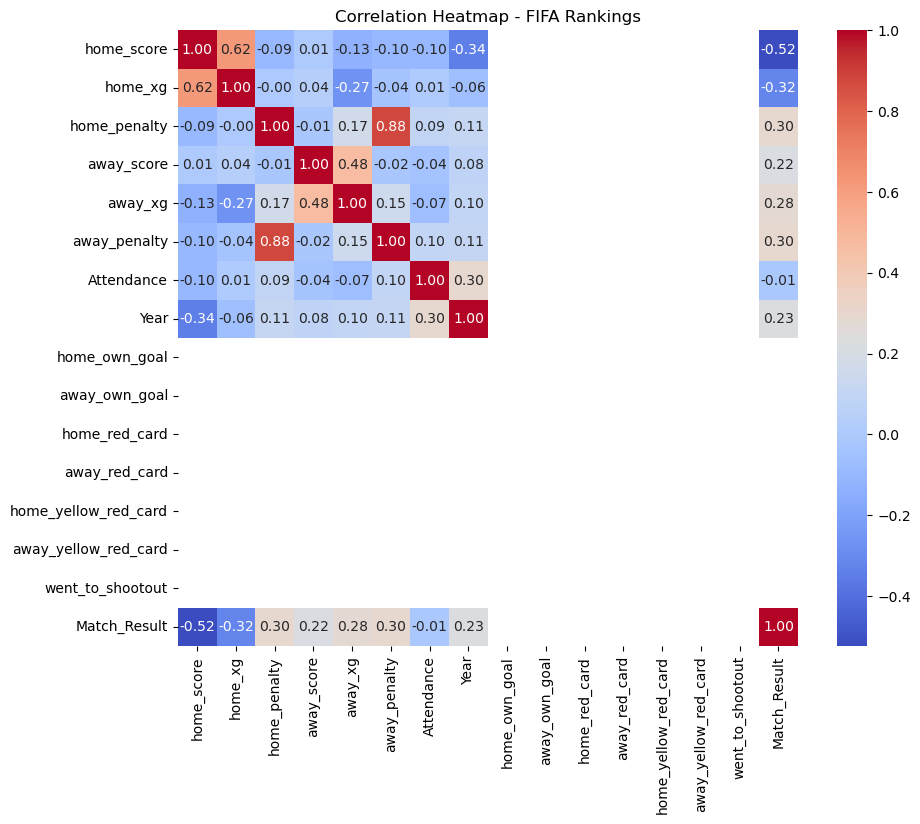

In [12]:
numeric_df = df_matches.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap - FIFA Rankings')
    plt.show()
else:
    print('Not enough numeric columns to display correlation heatmap for FIFA Rankings.')

<Axes: xlabel='count', ylabel='home_team'>

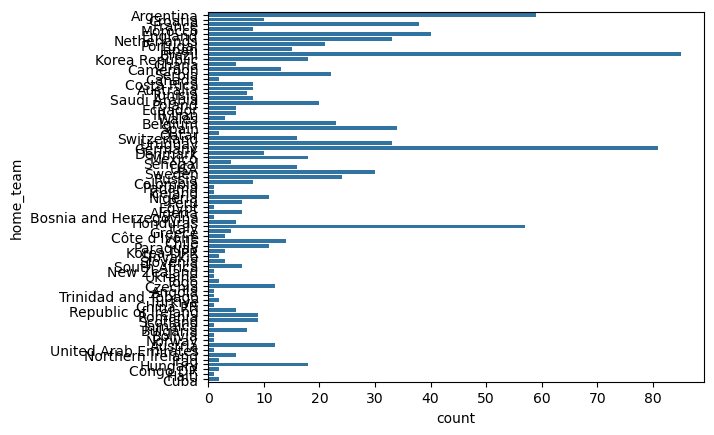

In [13]:
sns.countplot(df_matches['home_team'])

(array([208., 281., 228., 128.,  64.,  20.,  20.,   8.,   4.,   3.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

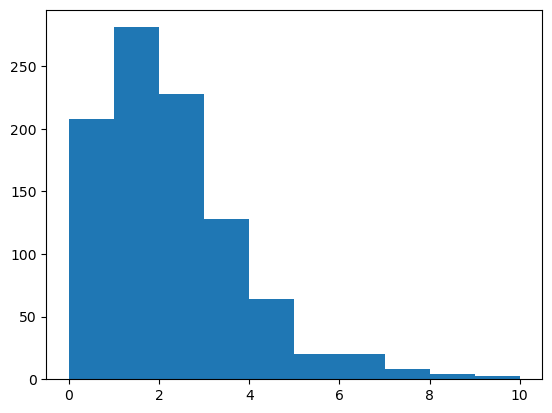

In [14]:
plt.hist(df_matches['home_score'],)

In [15]:
df_matches['Round'].isnull().sum()

np.int64(0)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26220\2451523012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


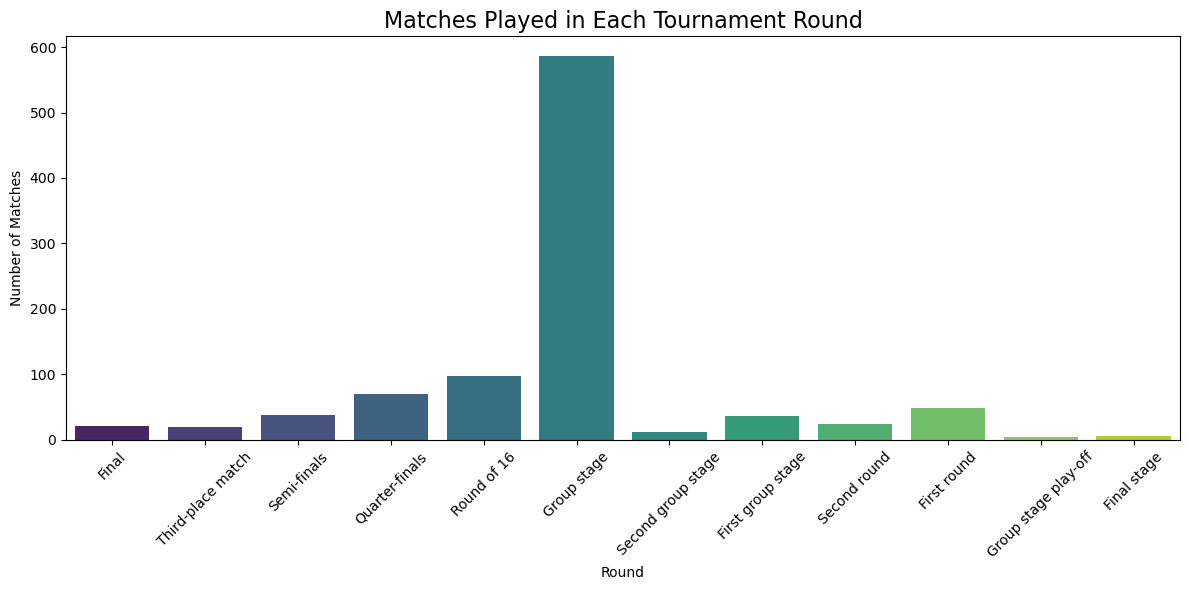

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_matches,
    x='Round',
    order=df_matches['Round'].drop_duplicates(),
    palette='viridis'
)

plt.title("Matches Played in Each Tournament Round", fontsize=16)
plt.xlabel("Round")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

from the above graph we can see that the most no. of matches played are in the group stage and as we go towards the final the no. of matches played reduces 

In [17]:
import pandas as pd


df_2022 = df_2022[['team', 'rank', 'points']]


# Merge Home Team Rankings

df_merged = df_matches.merge(
    df_2022,
    left_on='home_team',
    right_on='team',
    how='left'
)

df_merged.rename(columns={
    'rank': 'home_rank',
    'points': 'home_points'
}, inplace=True)

df_merged.drop(columns='team', inplace=True)


# Merge Away Team Rankings

df_merged = df_merged.merge(
    df_2022,
    left_on='away_team',
    right_on='team',
    how='left'
)

df_merged.rename(columns={
    'rank': 'away_rank',
    'points': 'away_points'
}, inplace=True)

df_merged.drop(columns='team', inplace=True)

# ------------------------------------
# Save the merged dataset (Optional)
# ------------------------------------
df_merged.to_csv("matches_with_rankings.csv", index=False)

# Preview
print(df_merged[['home_team', 'home_rank', 'home_points',
                 'away_team', 'away_rank', 'away_points']].head())

   home_team  home_rank  home_points away_team  away_rank  away_points
0  Argentina          3      1773.88    France          4      1759.78
1    Croatia         12      1645.64   Morocco         22      1563.50
2     France          4      1759.78   Morocco         22      1563.50
3  Argentina          3      1773.88   Croatia         12      1645.64
4    Morocco         22      1563.50  Portugal          9      1676.56


In [18]:
df_merged[[
    'home_rank',
    'away_rank',
    'home_points',
    'away_points',
    'home_score',
    'away_score'
]].describe()

,home_rank,away_rank,home_points,away_points,home_score,away_score
count,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000
mean,19.813278,26.439834,1627.182168,1578.556421,1.776971,1.044606
std,20.631675,23.720979,140.868086,143.540331,1.596676,1.071233
min,1.000000,1.000000,978.650000,978.650000,0.000000,0.000000
25%,5.000000,9.000000,1509.610000,1492.200000,1.000000,0.000000
50%,12.000000,21.000000,1645.640000,1563.620000,1.000000,1.000000
75%,29.000000,36.000000,1728.470000,1676.560000,3.000000,2.000000
max,167.000000,167.000000,1841.300000,1841.300000,10.000000,7.000000


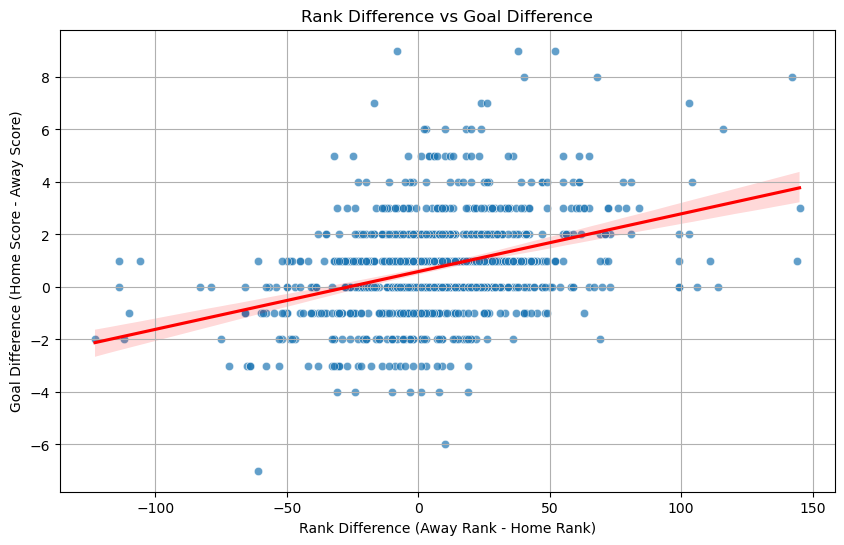

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create new features
df_merged['rank_difference'] = df_merged['away_rank'] - df_merged['home_rank']
df_merged['goal_difference'] = df_merged['home_score'] - df_merged['away_score']

# Scatter Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_merged,
    x='rank_difference',
    y='goal_difference',
    alpha=0.7
)

# Add regression line
sns.regplot(
    data=df_merged,
    x='rank_difference',
    y='goal_difference',
    scatter=False,
    color='red'
)

plt.title('Rank Difference vs Goal Difference')
plt.xlabel('Rank Difference (Away Rank - Home Rank)')
plt.ylabel('Goal Difference (Home Score - Away Score)')
plt.grid(True)

plt.show()

home_rank        12.00
away_rank        21.00
home_points    1645.64
away_points    1563.62
home_score        1.00
away_score        1.00
dtype: float64

========== Correlation Matrix ==========

                 home_rank  away_rank  home_points  away_points  home_score  \
home_rank         1.000000   0.002052    -0.942381     0.000220   -0.152889   
away_rank         0.002052   1.000000     0.002284    -0.953357    0.197529   
home_points      -0.942381   0.002284     1.000000    -0.010526    0.152185   
away_points       0.000220  -0.953357    -0.010526     1.000000   -0.188467   
home_score       -0.152889   0.197529     0.152185    -0.188467    1.000000   
away_score        0.204948  -0.183156    -0.195659     0.190981    0.005215   
rank_difference  -0.655382   0.753951     0.620806    -0.720214    0.249632   
goal_difference  -0.241731   0.266720     0.235957    -0.263547    0.829517   
Match_Result      0.161163  -0.082418    -0.172621     0.094902   -0.523627   

             

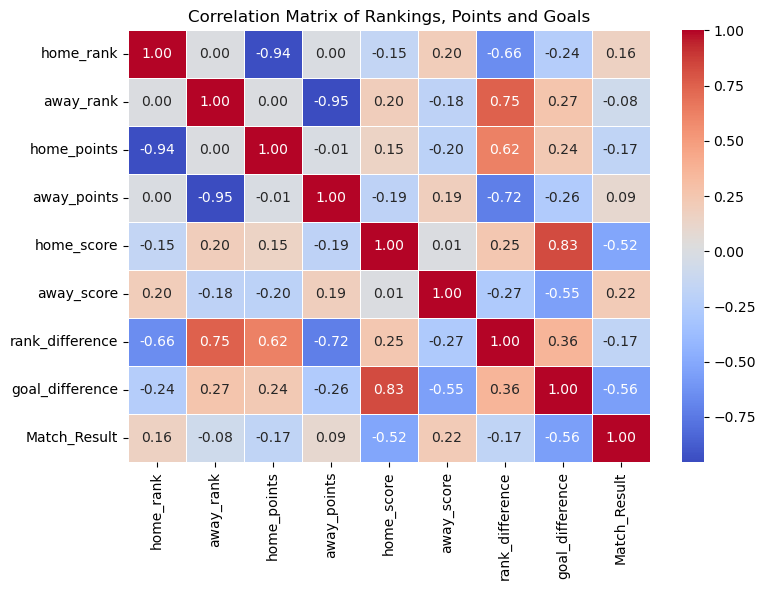

In [ ]:
print(df_merged[[
    'home_rank',
    'away_rank',
    'home_points',
    'away_points',
    'home_score',
    'away_score'
]].median())

corr = df_merged[[
    'home_rank',
    'away_rank',
    'home_points',
    'away_points',
    'home_score',
    'away_score','rank_difference',
    'goal_difference','Match_Result'
]].corr()

print("\n========== Correlation Matrix ==========\n")
print(corr)


plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Rankings, Points and Goals")
plt.tight_layout()
plt.show()

From the above correlation heatmap we can see that goal_difference and rank_difference has positive correlation 
means as goal difference increases the rank differense also increases. this same is also for goal difference and 
match result . infact goal difference is highly positively correlated with match result ,similarly home_score is positively correlated with rank difference . 


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26220\2341515509.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


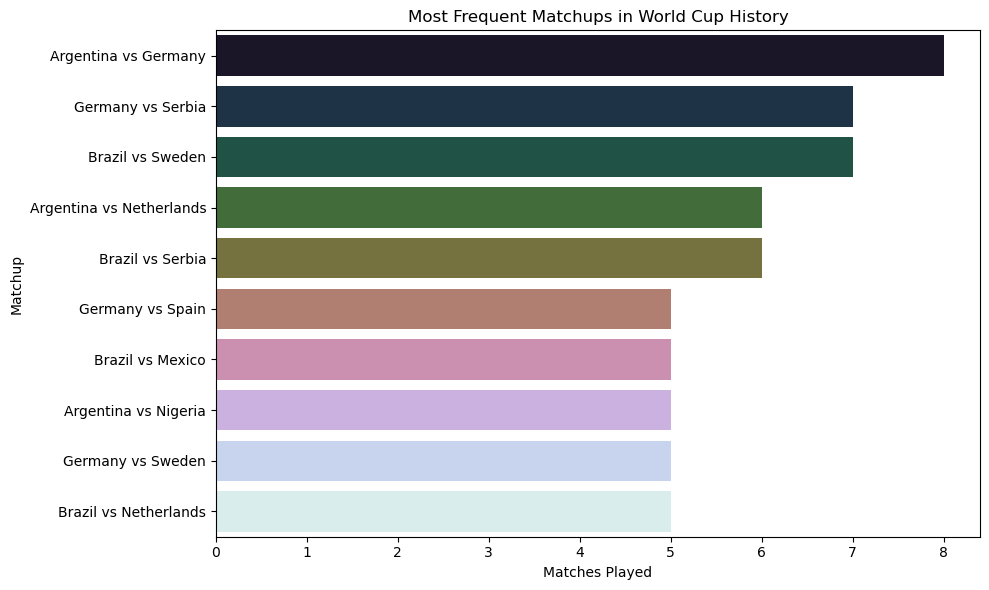

The most played matchup is Argentina vs Germany (8 times).


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# Create a matchup column (order independent)
df_matches['matchup'] = df_matches.apply(
    lambda row: ' vs '.join(sorted([row['home_team'], row['away_team']])),
    axis=1
)

# Find the 10 most frequent matchups
top_matchups = (
    df_matches['matchup']
    .value_counts()
    .head(10)
    .reset_index()
)

top_matchups.columns = ['Matchup', 'Matches Played']

# Plot
sns.barplot(
    data=top_matchups,
    y='Matchup',
    x='Matches Played',
    palette='cubehelix',
    ax=ax
)

ax.set_title('Most Frequent Matchups in World Cup History')
ax.set_xlabel('Matches Played')
ax.set_ylabel('Matchup')

plt.tight_layout()
plt.show()

# Insight
print(
    f"The most played matchup is "
    f"{top_matchups.iloc[0]['Matchup']} "
    f"({top_matchups.iloc[0]['Matches Played']} times)."
)


the above graph shows the most frequent no. of matches played btw any two countries . Argentina and Germany are the one who played most frequenty with each other and had played more than 8 matches against each other 


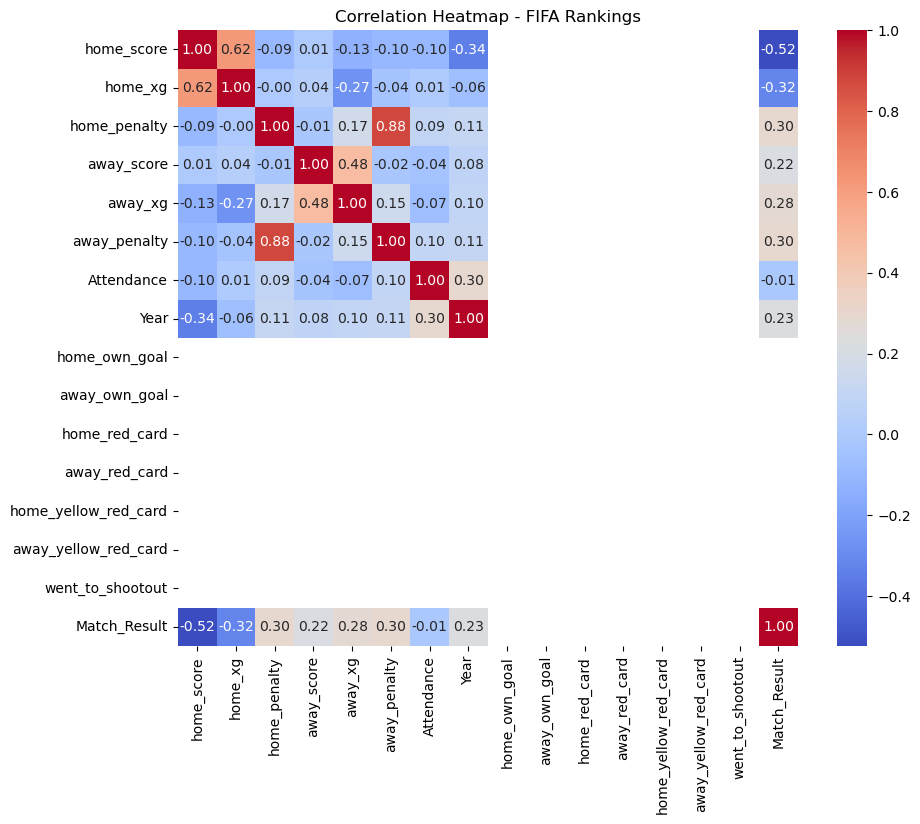

In [22]:
numeric_df_merged = df_merged.select_dtypes(include=[np.number])
if numeric_df_merged.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap - FIFA Rankings')
    plt.show()
else:
    print('Not enough numeric columns to display correlation heatmap for FIFA Rankings.')

<Figure size 1000x800 with 0 Axes>

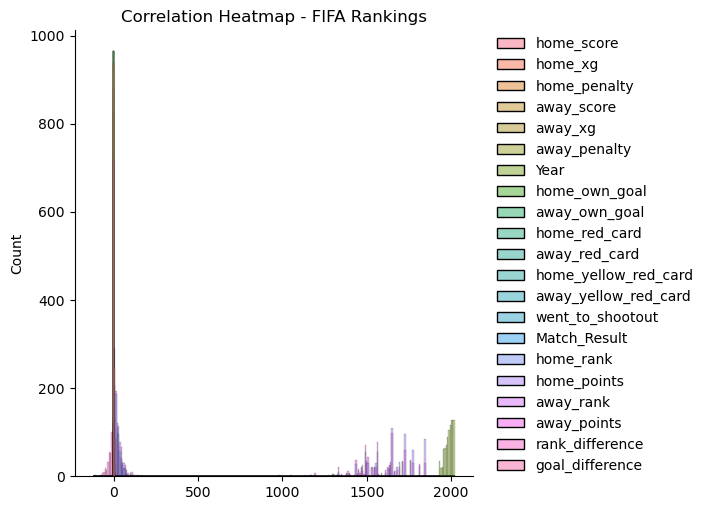

In [23]:
numeric_df_merged = df_merged.select_dtypes(include=[np.number])
if numeric_df_merged.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    sns.displot(numeric_df_merged.drop(columns=['Attendance']))
    plt.title('Correlation Heatmap - FIFA Rankings')
    plt.show()
else:
    print('Not enough numeric columns to display correlation heatmap for FIFA Rankings.')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26220\2763060571.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=total_goals,x='Team',y='Goals', palette='viridis')


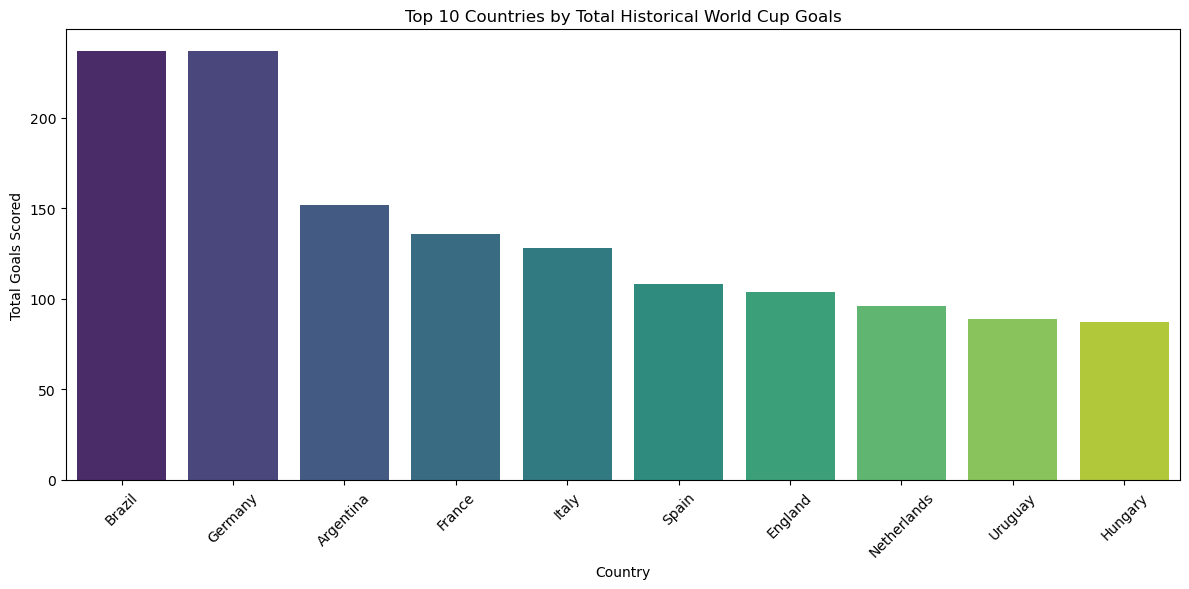

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Goals scored as home team
home_goals = (
    df_matches.groupby('home_team')['home_score']
    .sum()
    .reset_index()
    .rename(columns={
        'home_team': 'Team',
        'home_score': 'Goals'
    })
)

# Goals scored as away team
away_goals = (
    df_matches.groupby('away_team')['away_score']
    .sum()
    .reset_index()
    .rename(columns={
        'away_team': 'Team',
        'away_score': 'Goals'
    })
)

# Combine home and away goals
total_goals = pd.concat([home_goals, away_goals])

# Total goals by each country
total_goals = (
    total_goals.groupby('Team')['Goals']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot( data=total_goals,x='Team',y='Goals', palette='viridis')

plt.title('Top 10 Countries by Total Historical World Cup Goals')
plt.xlabel('Country')
plt.ylabel('Total Goals Scored')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

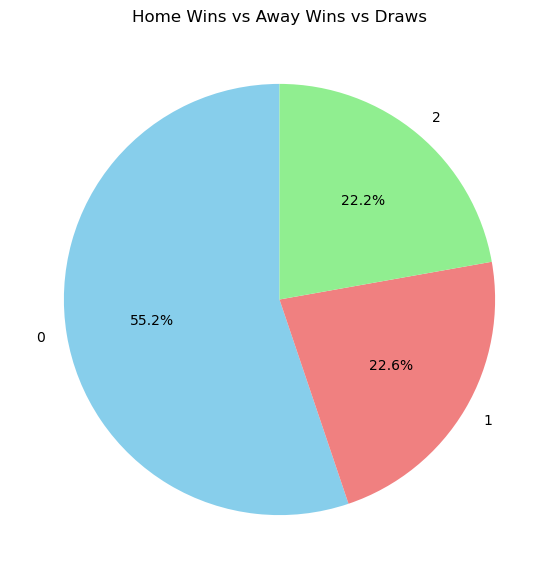

In [25]:
result_counts = df_merged['Match_Result'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightcoral', 'lightgreen']
)

plt.title('Home Wins vs Away Wins vs Draws')

plt.show()

In [26]:
x=df_matches.groupby(df_matches['home_score']==df_matches['away_score'])

In [27]:
x=df_matches.np.where(df_matches[''])

AttributeError: 'DataFrame' object has no attribute 'np'

In [28]:
x

In [29]:
import pandas as pd

# Count missing values
missing_values = df_matches.isnull().sum()

# Calculate percentage
missing_percentage = (missing_values / len(df_matches)) * 100

# Create summary dataframe
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display columns having missing values only
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

# Sort in descending order
missing_summary = missing_summary.sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)

                                 Missing Values  Percentage (%)
home_penalty_miss_long                      958       99.377593
away_penalty_miss_long                      955       99.066390
home_penalty_shootout_miss_long             940       97.510373
away_penalty_shootout_miss_long             934       96.887967
home_penalty_shootout_goal_long             930       96.473029
away_penalty_shootout_goal_long             930       96.473029
Notes                                       891       92.427386
away_penalty_goal                           880       91.286307
home_penalty_goal                           848       87.966805
home_xg                                     836       86.721992
away_xg                                     836       86.721992
away_goal                                   393       40.767635
away_goal_long                              393       40.767635
home_yellow_card_long                       343       35.580913
away_yellow_card_long                   

above are the columns in the dataset of matches_1930_2022 in the decreasing order of their missing values ,the percentage of values that are missing is also written 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26220\1056239866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


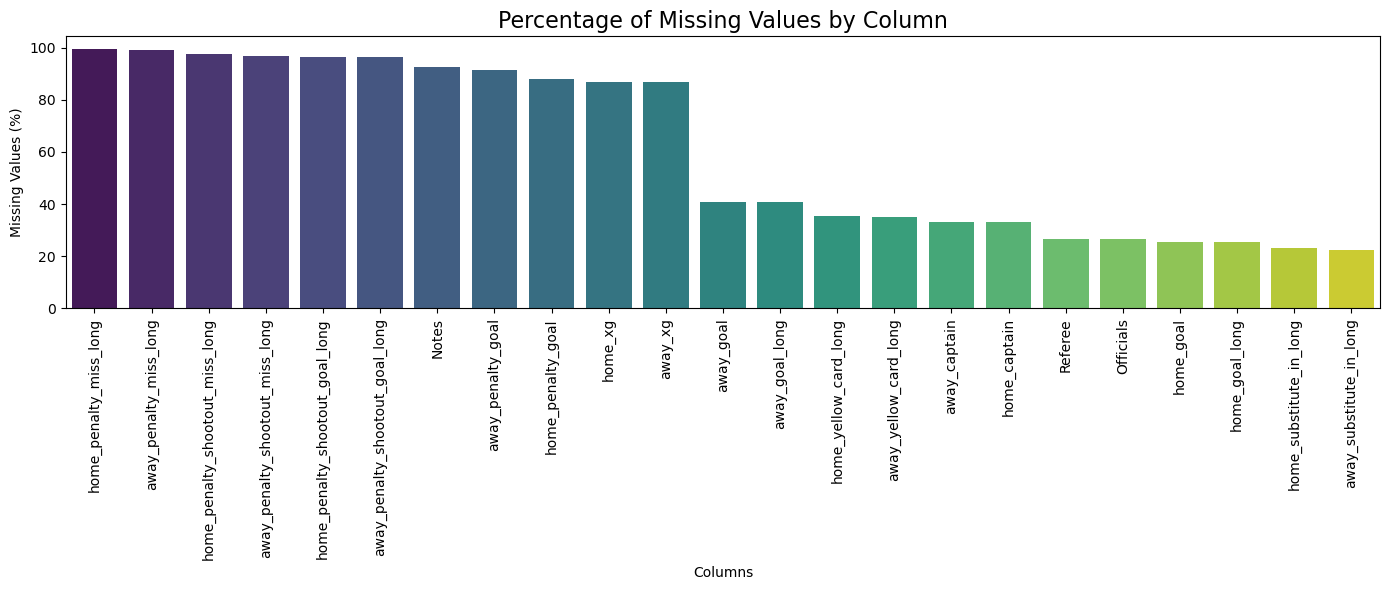

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary['Percentage (%)'],
    palette='viridis'
)

plt.title("Percentage of Missing Values by Column", fontsize=16)
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [26]:
df_matches['home_yellow_card_long'].head(2)

0    ['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...
1                                                  NaN
Name: home_yellow_card_long, dtype: str

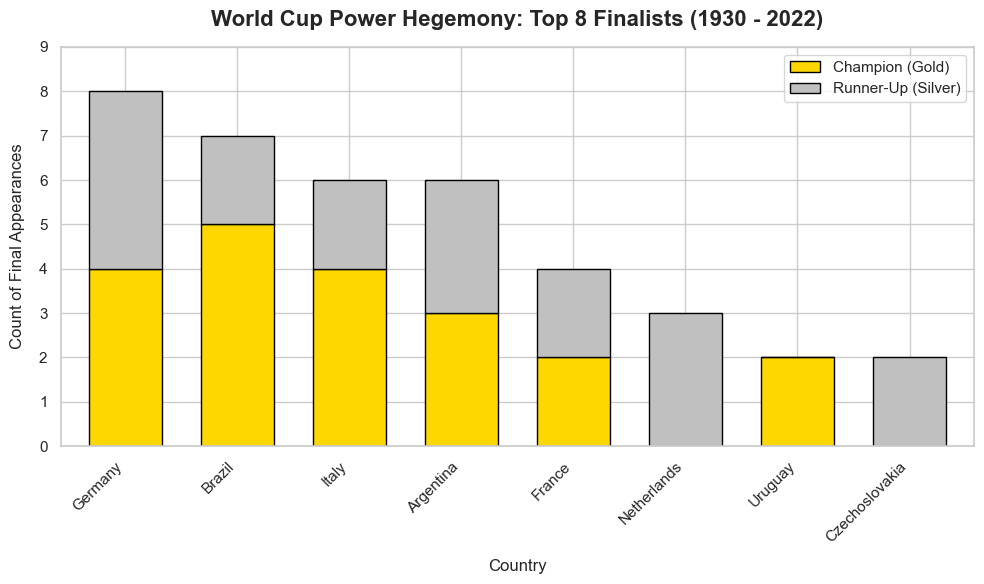

In [32]:

df_world_cup['Champion'] = df_world_cup['Champion'].replace('West Germany', 'Germany')
df_world_cup['Runner-Up'] = df_world_cup['Runner-Up'].replace('West Germany', 'Germany')


champs = df_world_cup['Champion'].value_counts().rename('Champion')
runners = df_world_cup['Runner-Up'].value_counts().rename('Runner-Up')


finalists = pd.concat([champs, runners], axis=1).fillna(0).astype(int)
finalists['Total'] = finalists['Champion'] + finalists['Runner-Up']


finalists = finalists.sort_values(by=['Total', 'Champion'], ascending=False).head(8)


sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))


finalists[['Champion', 'Runner-Up']].plot(
    kind='bar', 
    stacked=True, 
    color=['#FFD700', '#C0C0C0'], 
    ax=ax, 
    edgecolor='black',
    width=0.65
)


ax.set_title('World Cup Power Hegemony: Top 8 Finalists (1930 - 2022)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12, labelpad=10)
ax.set_ylabel('Count of Final Appearances', fontsize=12, labelpad=10)
ax.set_xticklabels(finalists.index, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(0, finalists['Total'].max() + 2, 1))


ax.legend(['Champion (Gold)', 'Runner-Up (Silver)'], fontsize=11, loc='upper right')

plt.tight_layout()


plt.show()

"The graph above shows which countries have won the World Cup and how many times they were runners-up."

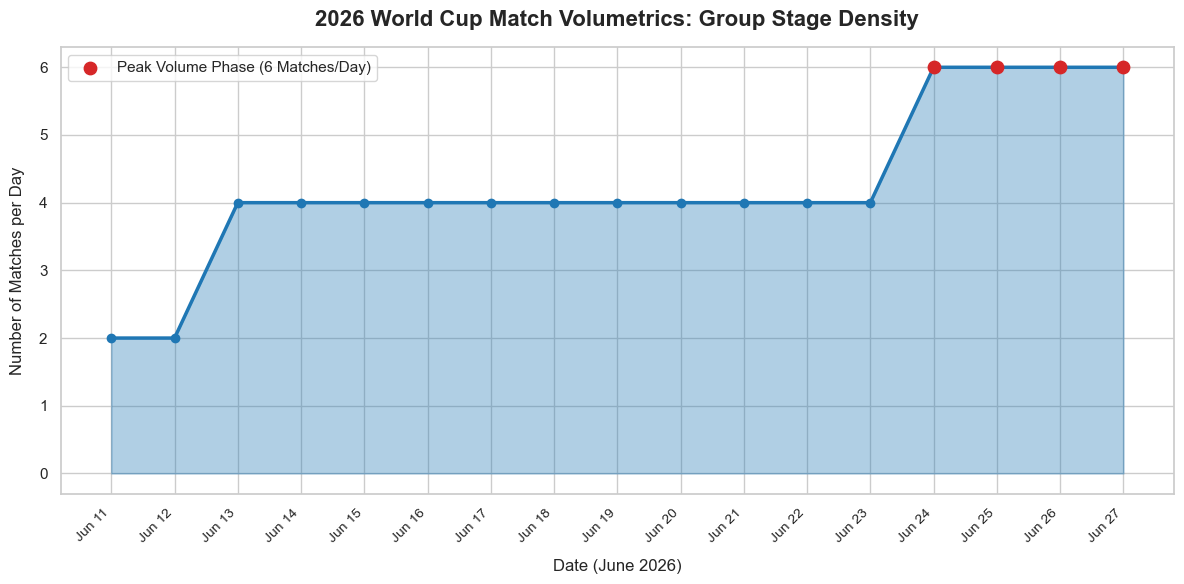

In [34]:
import matplotlib.dates as mdates



df_sched = pd.read_csv('schedule_2026.csv')


df_sched['Date'] = pd.to_datetime(df_sched['Date'])


match_counts = df_sched.groupby('Date').size().reset_index(name='Match Count')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))


ax.fill_between(match_counts['Date'], match_counts['Match Count'], color='#1f77b4', alpha=0.35)
ax.plot(match_counts['Date'], match_counts['Match Count'], color='#1f77b4', linewidth=2.5, marker='o', markersize=6)


ax.set_title('2026 World Cup Match Volumetrics: Group Stage Density', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date (June 2026)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Matches per Day', fontsize=12, labelpad=10)


ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(0, match_counts['Match Count'].max() + 2, 1))


peak_days = match_counts[match_counts['Match Count'] == 6]
ax.scatter(peak_days['Date'], peak_days['Match Count'], color='#d62728', s=80, zorder=5, label='Peak Volume Phase (6 Matches/Day)')
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()


plt.show()



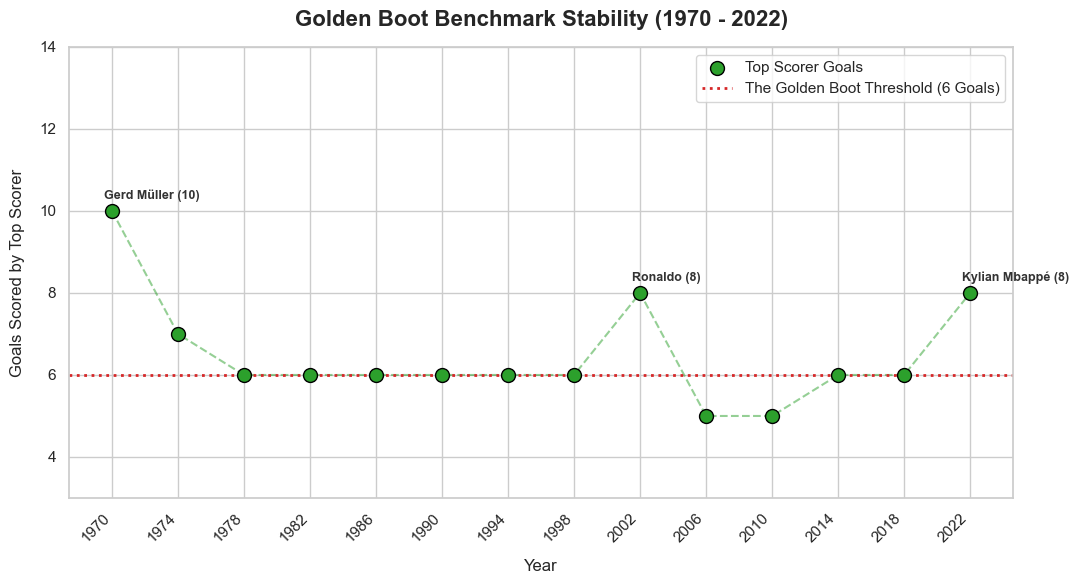

In [ ]:
import re




# 2. Function to extract the goal count from strings like "Kylian Mbappé - 8"
def extract_goals(text):
    match = re.search(r'-\s*(\d+)', str(text))
    return int(match.group(1)) if match else None

df_world_cup['Goals'] = df_world_cup['TopScorrer'].apply(extract_goals)
df_modern = df_world_cup[df_world_cup['Year'] >= 1970].sort_values(by='Year')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))


ax.plot(df_modern['Year'], df_modern['Goals'], color='#2ca02c', alpha=0.5, linestyle='--', linewidth=1.5)
ax.scatter(df_modern['Year'], df_modern['Goals'], color='#2ca02c', s=100, edgecolors='black', zorder=3, label='Top Scorer Goals')


ax.axhline(y=6, color='#d62728', linestyle=':', linewidth=2, label='The Golden Boot Threshold (6 Goals)')


for idx, row in df_modern.iterrows():
    if row['Goals'] >= 8:
       
        name = row['TopScorrer'].split(' - ')[0].split(',')[0] 
        ax.annotate(f"{name} ({row['Goals']})", 
                    xy=(row['Year'], row['Goals']),
                    xytext=(row['Year'] - 0.5, row['Goals'] + 0.3),
                    fontsize=9, fontweight='bold', color='#333333')

ax.set_title('Golden Boot Benchmark Stability (1970 - 2022)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Goals Scored by Top Scorer', fontsize=12, labelpad=10)

ax.set_xticks(df_modern['Year'])
plt.xticks(rotation=45, ha='right')
ax.set_ylim(3, 14)
ax.set_yticks(range(4, 15, 2))

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


